### Coding Question: Image Classification Neural Network

Using the dataset provided below, design and implement a **Neural Network for multi-class image classification**.

**Dataset:** [Nepali Numbers and Letters Dataset](https://github.com/ShaileshAdhikari/nepali-text-classification/blob/main/images.rar)

Your implementation should include:

1. **Data Preparation**

   * Load, preprocess, resize, normalize, and split the dataset into train/validation/test sets.

2. **Neural Network**

3. **Hyperparameter Tuning**

4. **Evaluation**
   Evaluate the final model using:

   * Accuracy
   * Precision
   * Recall
   * F1-score
   * Macro/Weighted F1
   * Confusion Matrix

5. **Performance Analysis**

**Deliverable:** Complete, reproducible code with a final report comparing the experimented configurations and their performance.


In [25]:
# Your Solution

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

Set random seeds

In [27]:
import random
SEED = 69
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Delete corrupt images

In [28]:
# Remove corrupted images
DATA_DIR = Path(r"F:\Data-Science\images")


deleted = 0

for path in DATA_DIR.rglob("*"):
    if path.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]:
        try:
            with Image.open(path) as img:
                img.verify()
        except Exception:
            path.unlink()
            deleted += 1

print("Corrupted images deleted:", deleted)

Corrupted images deleted: 0


Load and preprocesss dataset

In [29]:
IMAGE_SIZE = (32, 32)

class_names = sorted([
    folder.name for folder in DATA_DIR.iterdir()
    if folder.is_dir()
])

X = []
y = []

for label, class_name in enumerate(class_names):
    for path in (DATA_DIR / class_name).rglob("*"):
        if path.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]:
            try:
                image = Image.open(path).convert("RGB")
                image = image.resize(IMAGE_SIZE)

                X.append(np.array(image) / 255.0)
                y.append(label)

            except Exception:
                continue

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("Total images:", len(X))
print("Number of classes:", len(class_names))
print("Class names:", class_names)

Total images: 2033
Number of classes: 12
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'ba', 'pa']


count image in each class

In [30]:
for class_name in class_names:
    count = sum(
        1 for p in (DATA_DIR / class_name).rglob("*")
        if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
    )

    print(f"{class_name}: {count} images")

0: 96 images
1: 171 images
2: 176 images
3: 186 images
4: 206 images
5: 194 images
6: 159 images
7: 147 images
8: 135 images
9: 123 images
ba: 206 images
pa: 234 images


Preview sample images

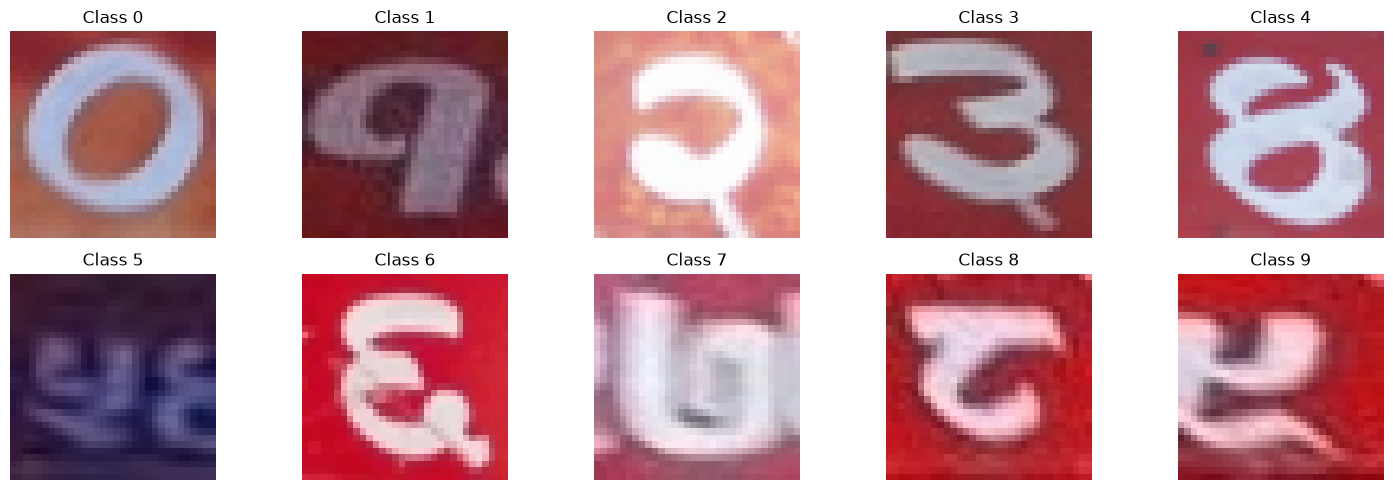

In [31]:
plt.figure(figsize=(15, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    index = np.where(y == i)[0][0]
    plt.imshow(X[index])
    plt.title(f"Class {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Split dataset. 70& train, 15% validate, 15% test

In [32]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Testing images:", len(X_test))

Training images: 1423
Validation images: 305
Testing images: 305


Build CNN model

In [33]:

def create_model(filters=32, dropout=0.3):

    model = Sequential([
        tf.keras.Input(shape=(32, 32, 3)),

        Conv2D(filters, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),

        Conv2D(filters * 2, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation="relu"),
        Dropout(dropout),

        Dense(len(class_names), activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## Hyper parameter tuning
compare 2 cnn configs using different numbers of filters

In [34]:
results = []

for filters in [16, 32]:
    for dropout in [0.3, 0.5]:

        model = create_model(filters, dropout)

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=4,
            batch_size=30,
            verbose=1
        )

        results.append({
            "filters": filters,
            "dropout": dropout,
            "val_accuracy": max(history.history["val_accuracy"])
        })

for result in results:
    print(result)

best_config = max(results, key=lambda x: x["val_accuracy"])

print("\nBest configuration:", best_config)

Epoch 1/4
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.1413 - loss: 2.4184 - val_accuracy: 0.3541 - val_loss: 2.2327
Epoch 2/4
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3970 - loss: 1.9121 - val_accuracy: 0.6426 - val_loss: 1.4188
Epoch 3/4
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6304 - loss: 1.2991 - val_accuracy: 0.7639 - val_loss: 0.9718
Epoch 4/4
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7273 - loss: 0.9459 - val_accuracy: 0.8066 - val_loss: 0.8212
Epoch 1/4
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1244 - loss: 2.4551 - val_accuracy: 0.3705 - val_loss: 2.3404
Epoch 2/4
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2902 - loss: 2.1425 - val_accuracy: 0.6164 - val_loss: 1.6421
Epoch 3/4
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4807 - loss: 1.6168 - val_accuracy: 0.7475 - val_loss: 1.1958
Epoch 4/4
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6058 - loss: 1.2576 - val_accuracy: 0.8066 - val_loss: 0.918

Train final model

In [35]:
final_model = create_model(
    best_config["filters"],
    best_config["dropout"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1673 - loss: 2.4029 - val_accuracy: 0.4885 - val_loss: 2.1225
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4793 - loss: 1.6961 - val_accuracy: 0.7541 - val_loss: 1.1037
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7077 - loss: 1.0589 - val_accuracy: 0.8295 - val_loss: 0.7307
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7765 - loss: 0.7988 - val_accuracy: 0.8525 - val_loss: 0.6254
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8103 - loss: 0.6345 - val_accuracy: 0.8689 - val_loss: 0.5176
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8468 - loss: 0.5363 - val_accuracy: 0.8918 - val_loss: 0.4423
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8728 - loss: 0.4450 - val_accuracy: 0.9049 - val_loss: 0.4033
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8756 - loss: 0.4067 - val_accuracy: 0.9279 - v

Evaluate the model

In [36]:
y_pred = np.argmax(final_model.predict(X_test), axis=1)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Macro Precision:",
      precision_score(y_test, y_pred, average="macro", zero_division=0))

print("Weighted Precision:",
      precision_score(y_test, y_pred, average="weighted", zero_division=0))

print("Macro Recall:",
      recall_score(y_test, y_pred, average="macro", zero_division=0))

print("Weighted Recall:",
      recall_score(y_test, y_pred, average="weighted", zero_division=0))

print("Macro F1-score:",
      f1_score(y_test, y_pred, average="macro", zero_division=0))

print("Weighted F1-score:",
      f1_score(y_test, y_pred, average="weighted", zero_division=0))

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    zero_division=0
))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Accuracy: 0.8885245901639345
Macro Precision: 0.888706648787294
Weighted Precision: 0.9064871278514853
Macro Recall: 0.8929093814355217
Weighted Recall: 0.8885245901639345
Macro F1-score: 0.8835735722723753
Weighted F1-score: 0.8914452055685226

Classification Report:

              precision    recall  f1-score   support

           0       0.54      0.93      0.68        15
           1       0.85      0.92      0.88        25
           2       0.87      1.00      0.93        27
           3       1.00      0.86      0.92        28
           4       1.00      0.84      0.91        31
           5       1.00      0.97      0.98        29
           6       0.92      0.92      0.92        24
           7       0.82      0.82      0.82        22
           8       1.00      0.95      0.97        20
           9       0.83      0.83      0.83        18
          ba       0.91      0.97      0.94        31
          pa       0.93      0.71      0.8

Confusion matrix

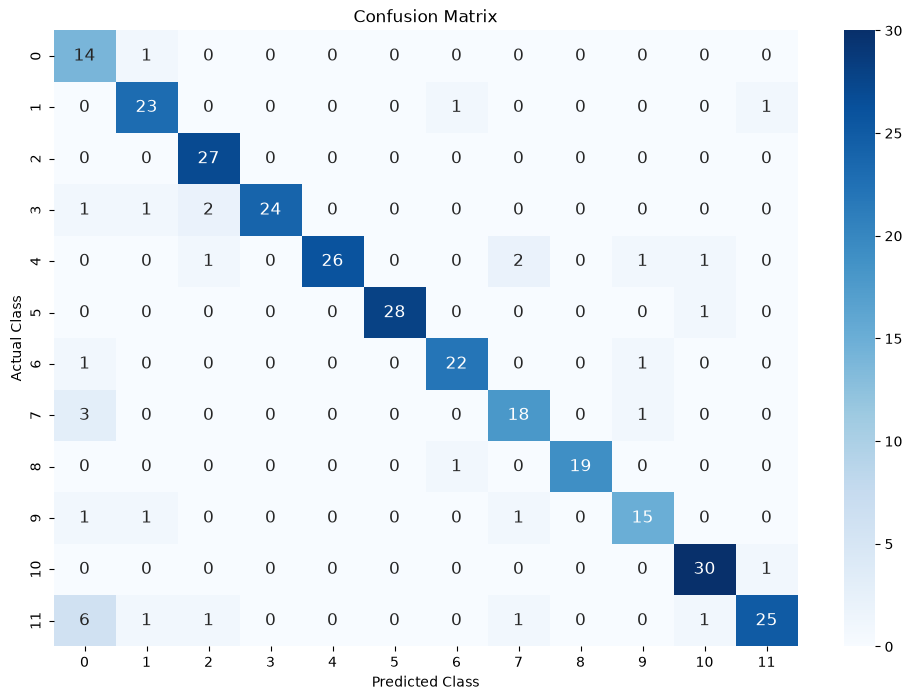

In [37]:
cm = confusion_matrix(
    y_test,
    y_pred,
    
    labels=np.arange(len(class_names))
)

plt.figure(figsize=(12, 8))

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", annot_kws={"size": 12})

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()

Plot training performance

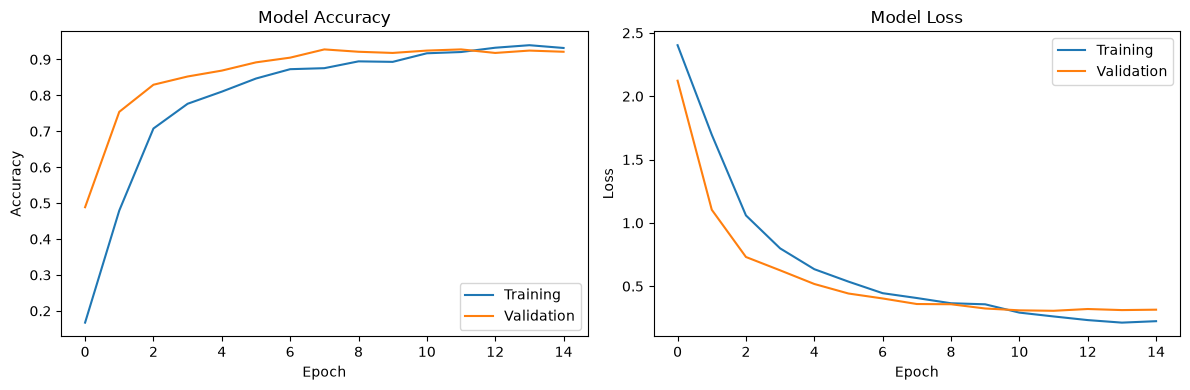

In [38]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Summary

In [39]:
train_accuracy = history.history["accuracy"][-1]
val_accuracy = history.history["val_accuracy"][-1]
train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]

print("Training Accuracy:", round(train_accuracy, 4))
print("Validation Accuracy:", round(val_accuracy, 4))
print("Training Loss:", round(train_loss, 4))
print("Validation Loss:", round(val_loss, 4))

if train_accuracy > val_accuracy + 0.1:
    print("Possible overfitting detected.")
elif val_loss > train_loss * 1.2:
    print("Possible overfitting: validation loss is higher.")
else:
    print("No strong overfitting signal from these final metrics.")

Training Accuracy: 0.9318
Validation Accuracy: 0.9213
Training Loss: 0.2239
Validation Loss: 0.3147
Possible overfitting: validation loss is higher.


## Model limitations
Image resolution: Resizing images to 32 × 32 pixels may remove important visual details. Dataset limitations: A small or imbalanced dataset may affect classification accuracy and generalization.
Model complexity: A simple CNN may not capture complex image features as effectively as more advanced architectures.
Hyperparameter tuning: Only four configurations are tested, so better configurations may exist.
Training limitations: The model may require more epochs or further tuning to achieve better performance.